## Problem 4: Gauss Updating Formula — Tetouan City Power Consumption

Implement the Gauss updating algorithm (G1)–(G4) from Chapter 11 using the Tetouan City power consumption dataset (first 2,016 observations). The outcome is **Zone 1 Power Consumption** and the features are Temperature, Humidity, Wind Speed, general diffuse flows, and diffuse flows.

**(1)** Fit an initial model using the first week of data (first 1,008 observations).

**(2)** Implement the Gauss updating formula treating the second week's data as new data, updating sequentially. The algorithm proceeds as follows:

- **(G1)** Initialize $V_{(n)} = (X_{(n)}^\top X_{(n)})^{-1}$ and $\hat{\beta}_{(n)}$ via OLS on the first-week data.
- **(G2)** For each new observation $x_{n+1}, y_{n+1}$, update the inverse:
$$V_{(n+1)} = V_{(n)} - \left\{1 + x_{n+1}^\top V_{(n)} x_{n+1}\right\}^{-1} V_{(n)} x_{n+1} x_{n+1}^\top V_{(n)}.$$
- **(G3)** Calculate $\gamma_{(n+1)} = V_{(n+1)} x_{n+1}$ and the predicted residual $\hat{\varepsilon}_{[n+1]} = y_{n+1} - x_{n+1}^\top \hat{\beta}_{(n)}$.
- **(G4)** Update the coefficient: $\hat{\beta}_{(n+1)} = \hat{\beta}_{(n)} + \gamma_{(n+1)} \hat{\varepsilon}_{[n+1]}$.

Plot the Temperature coefficient over time as the model is updated through the second week.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv


df = pd.read_csv('tetuan_city_power_consumption.csv')
# only first 2016 observations
df = df.iloc[:2016]

feature_cols = ['Temperature', 'Humidity', 'Wind Speed', 
                'general diffuse flows', 'diffuse flows']
outcome_col  = 'Zone 1 Power Consumption'

X_all = df[feature_cols].values
y_all = df[outcome_col].values

# adding intercept
X_all = np.hstack([np.ones((len(X_all), 1)), X_all])

# split by weeks
X1, y1 = X_all[:1008], y_all[:1008]
X2, y2 = X_all[1008:], y_all[1008:]

In [8]:
# (G1) Initial OLS fit on week 1
V = inv(X1.T @ X1)
beta = V @ X1.T @ y1

print("Initial coefficients:")
feature_names = ['Intercept'] + feature_cols
for name, coef in zip(feature_names, beta):
    print(f"{name}: {coef:.4f}")

Initial coefficients:
Intercept: 19663.6077
Temperature: 1480.6139
Humidity: -63.3735
Wind Speed: 1202.6786
general diffuse flows: -10.2263
diffuse flows: -20.3424


In [9]:
temp_coef_idx = 1  # temp is index 1 (after intercept)

# store temp coefficient after each update
temp_coefs = [beta[temp_coef_idx]] 

for t in range(len(X2)):
    x_new = X2[t] 
    y_new = y2[t]

    # (G2) 
    Vx = V @ x_new
    denom = 1 + x_new @ Vx
    V = V - np.outer(Vx, Vx) / denom

    # (G3)
    gamma = V @ x_new
    eps_hat = y_new - x_new @ beta

    # (G4) 
    beta = beta + gamma * eps_hat

    temp_coefs.append(beta[temp_coef_idx])

print(f"Final Temperature coefficient: {beta[temp_coef_idx]:.4f}")
print(f"Final Intercept: {beta[0]:.4f}")

Final Temperature coefficient: 1145.2810
Final Intercept: 9968.1269


/tmp/ipykernel_2394211/656555277.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


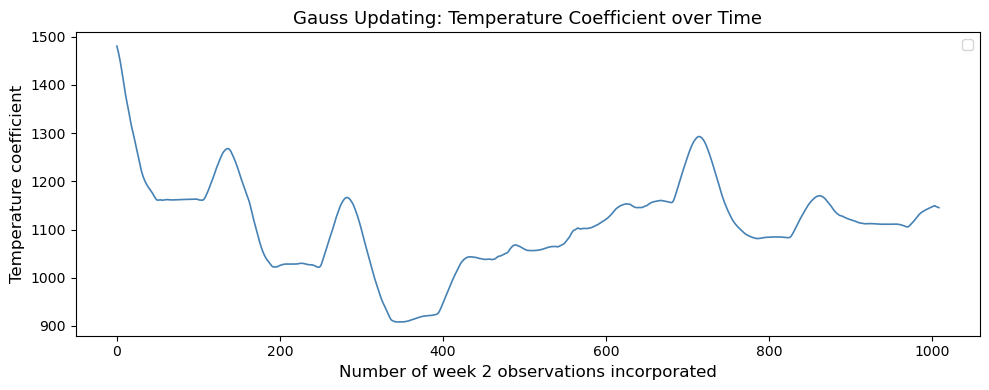

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(temp_coefs)), temp_coefs, color='steelblue', linewidth=1.2)

ax.set_xlabel('Number of week 2 observations incorporated', fontsize=12)
ax.set_ylabel('Temperature coefficient', fontsize=12)
ax.set_title('Gauss Updating: Temperature Coefficient over Time', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

The Temperature coefficient starts at approximately 1,480 and settles near 1,145 by the end of the second week, with the largest adjustments occurring early in the updating process when each new observation still carries substantial influence over the estimated coefficients.